# Module 3 — Appendiceal Cancer: Serious Outcomes

**Prerequisite:** Run `01_appendiceal_explore.ipynb` first to create the `appendiceal_reports` table.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

In [2]:

appendiceal_outcomes = pd.read_sql_query("""
SELECT outc_cod, COUNT(*) AS reports
FROM outc
JOIN (SELECT DISTINCT primaryid FROM appendiceal_cohort) f
    ON outc.primaryid = f.primaryid
GROUP BY outc_cod
ORDER BY reports DESC;
""", conn)
    
appendiceal_outcomes.head(10)

,outc_cod,reports
0,OT,85
1,HO,38
2,DE,17
3,LT,5


| Code | Outcome | Reports | Description |
|---|---|---|---|
| OT | Other Serious | 85 | Catch-all for serious events not fitting other categories - disability, required intervention, medically significant events |
| HO | Hospitalization | 38 | Required inpatient admission |
| DE | Death | 17 | Reported fatalities. Expected given late-stage diagnosis typical of appendiceal cancer |
| LT | Life-Threatening | 5 | Immediately life-threatening but non-fatal. Low count likely reflects underreporting rather than true rarity |

> Note: A single report can have multiple outcome codes so counts overlap. Total unique patients is smaller than the sum above.


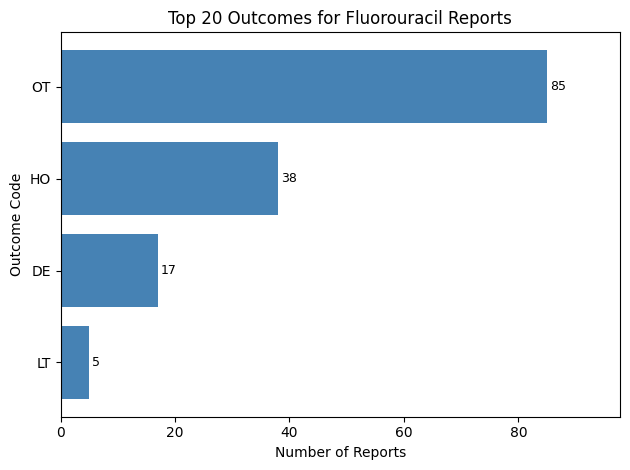

In [4]:
plt.barh(appendiceal_outcomes['outc_cod'][:20], appendiceal_outcomes['reports'][:20], color='steelblue')
plt.xlabel('Number of Reports')
plt.ylabel('Outcome Code')
plt.title('Top 20 Outcomes for Fluorouracil Reports')
plt.gca().invert_yaxis()
for i, (cod, val) in enumerate(zip(appendiceal_outcomes['outc_cod'][:20], appendiceal_outcomes['reports'][:20])):
    plt.text(val + 0.5, i, str(val), va='center', fontsize=9)
plt.xlim(0, appendiceal_outcomes['reports'].max() * 1.15)

plt.tight_layout()
plt.show()


# #
# | Code | Outcome |
# |------|---------|
# | DE | Death |
# | HO | Hospitalization |
# | LT | Life-threatening |
# | DS | Disability |
# | RI | Required intervention |
# | CA | Congenital anomaly |
# | OT | Other serious |

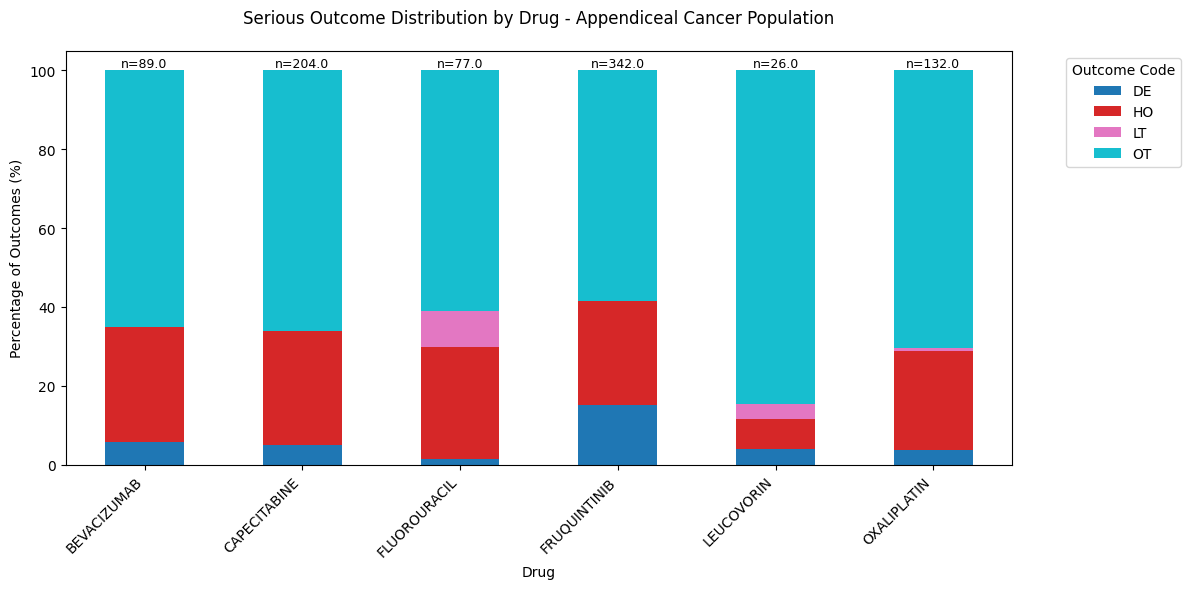

In [5]:
# Outcomes by drug in the appendiceal cancer population
# Joins appendiceal_cohort to outc on primaryid, filters to main drugs with enough reports
outcomes_by_drug = pd.read_sql_query("""
    SELECT ac.drugname, o.outc_cod, COUNT(*) AS reports
    FROM appendiceal_cohort ac
    JOIN outc o ON ac.primaryid = o.primaryid
    WHERE ac.drugname IN (
        'CAPECITABINE', 'OXALIPLATIN', 'FLUOROURACIL',
        'BEVACIZUMAB', 'LEUCOVORIN', 'FRUQUINTINIB'
    )
    AND o.outc_cod IN ('DE', 'HO', 'LT', 'OT')
    GROUP BY ac.drugname, o.outc_cod
    ORDER BY reports DESC
""", conn)

# Pivot to get drugs as columns, outcome codes as rows
pivot = outcomes_by_drug.pivot_table(
    index='outc_cod',
    columns='drugname',
    values='reports',
    fill_value=0
)

# Normalize to percentages within each drug column
pivot_pct = pivot.div(pivot.sum(axis=0), axis=1) * 100

# Stacked bar chart
pivot_pct.T.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.xlabel('Drug')
plt.ylabel('Percentage of Outcomes (%)')
plt.title('Serious Outcome Distribution by Drug - Appendiceal Cancer Population', pad=20)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Outcome Code', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add n= total above each bar
for i, drug in enumerate(pivot_pct.columns):
    total = pivot[drug].sum()
    plt.text(i, 101, f'n={total}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
